# Modelos — dataset Airfare ML (Índia)

O [Airfare ML](https://www.kaggle.com/datasets/yashdharme36/airfare-ml-predicting-flight-fares) tem cerca de 450 mil voos
entre sete grandes cidades da Índia, recolhidos no EaseMyTrip entre janeiro e março de 2023. Os preços são convertidos de rupias para euros.

Os modelos são treinados duas vezes: com os dados completos e depois de remover outliers pelo critério IQR.

In [1]:
from pathlib import Path

import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from flight_prices.airfare import NUMERIC_FEATURES, TARGET, build_pipeline, load_airfare, remove_outliers_iqr
from flight_prices.evaluation import (
    fit_and_predict,
    metrics_table,
    plot_error_comparison,
    plot_predictions_vs_actual,
    plot_residuals,
)

DATA_DIR = Path("../data")
UNIT = "EUR"
XGB_DEVICE = "cpu"

In [2]:
def build_models():
    return {
        "Linear Regression": build_pipeline(LinearRegression()),
        "Random Forest": build_pipeline(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        "XGBoost": build_pipeline(
            xgb.XGBRegressor(n_estimators=100, random_state=42, tree_method="hist", device=XGB_DEVICE)
        ),
    }


def run_experiment(data):
    X = data.drop(columns=TARGET)
    y = data[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return y_test, fit_and_predict(build_models(), X_train, y_train, X_test)


def plot_results(y_test, predictions):
    for name, y_pred in predictions.items():
        plot_predictions_vs_actual(name, y_test, y_pred, UNIT)
        plot_residuals(name, y_test, y_pred, UNIT)

In [3]:
data = load_airfare(DATA_DIR / "Cleaned_dataset.csv")

## Dados completos

In [4]:
y_test, predictions = run_experiment(data)

Linear Regression: treinado em 0.94s


Random Forest: treinado em 932.78s


XGBoost: treinado em 4.89s


In [5]:
metrics_full = metrics_table(y_test, predictions, UNIT)
metrics_full

,MAE (EUR),RMSE (EUR),R²
Linear Regression,56.975761,86.363594,0.853305
Random Forest,22.881703,47.136021,0.956302
XGBoost,33.440397,56.591830,0.937011


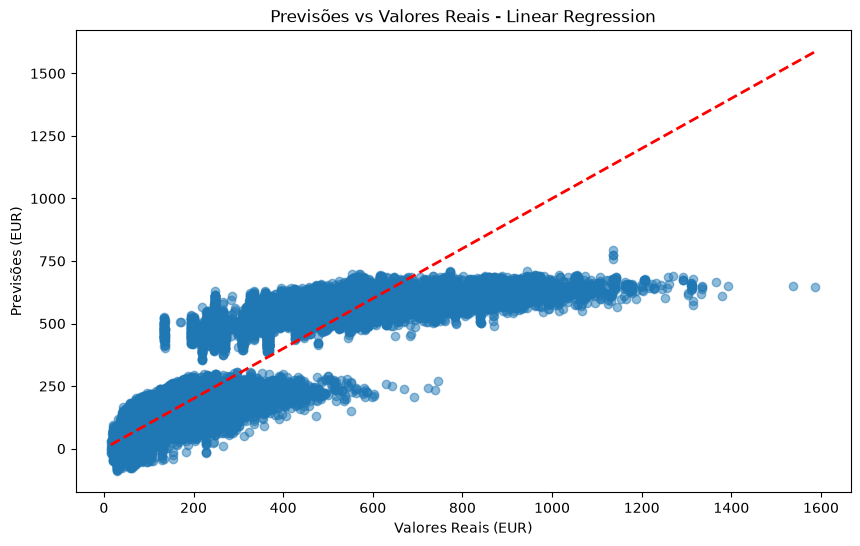

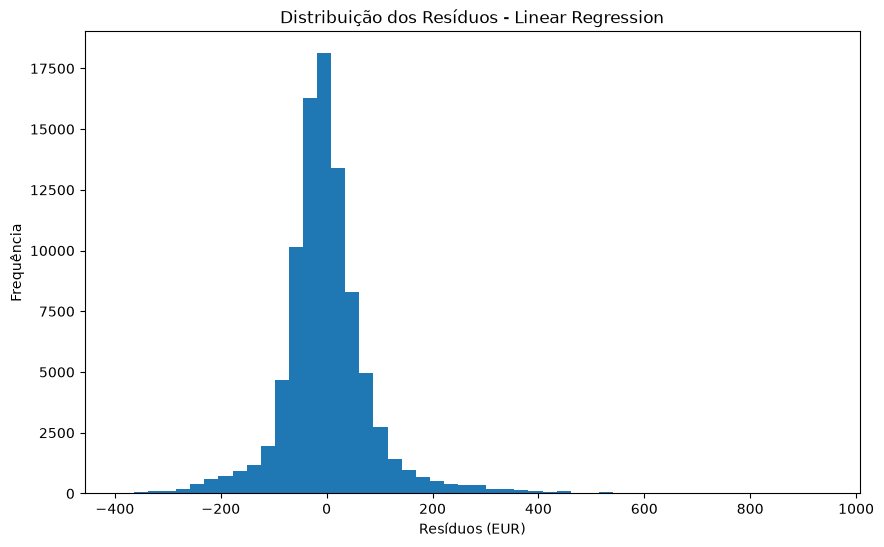

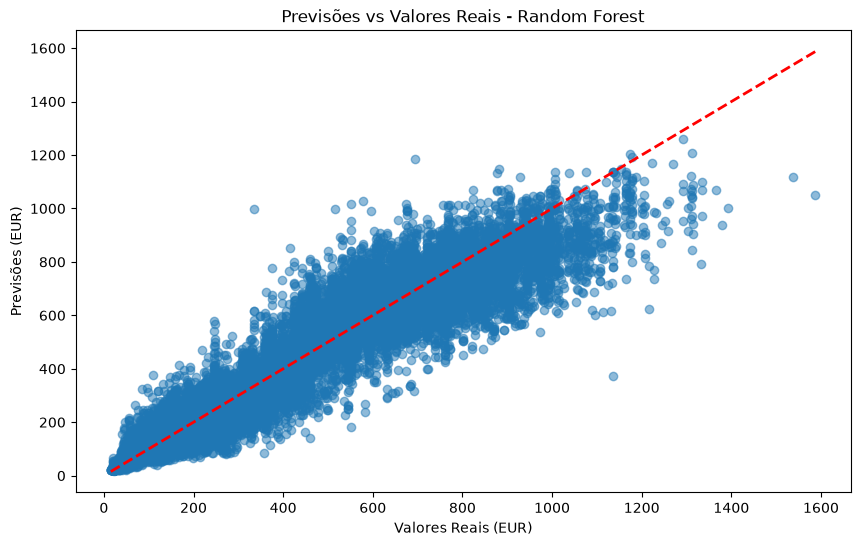

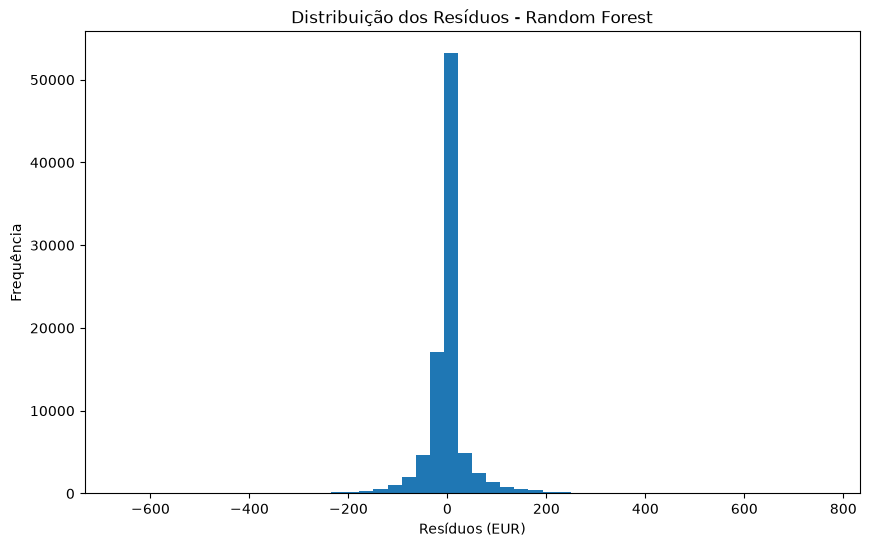

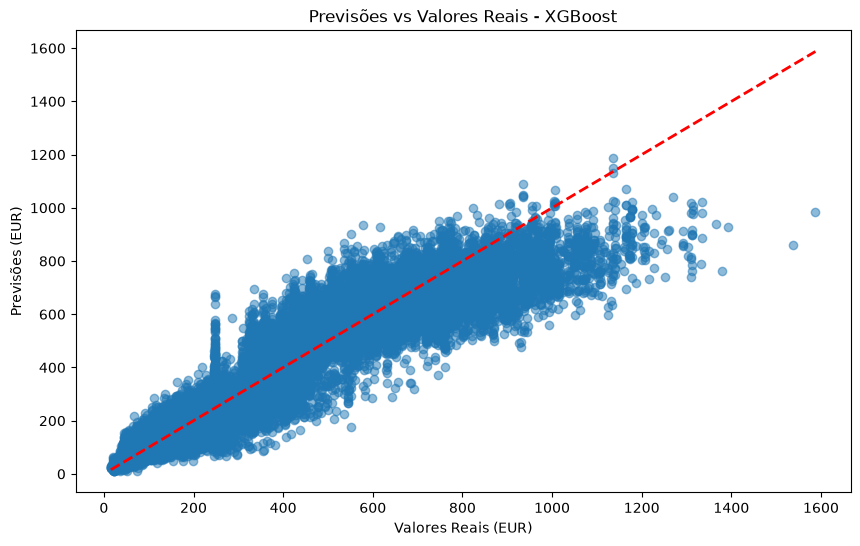

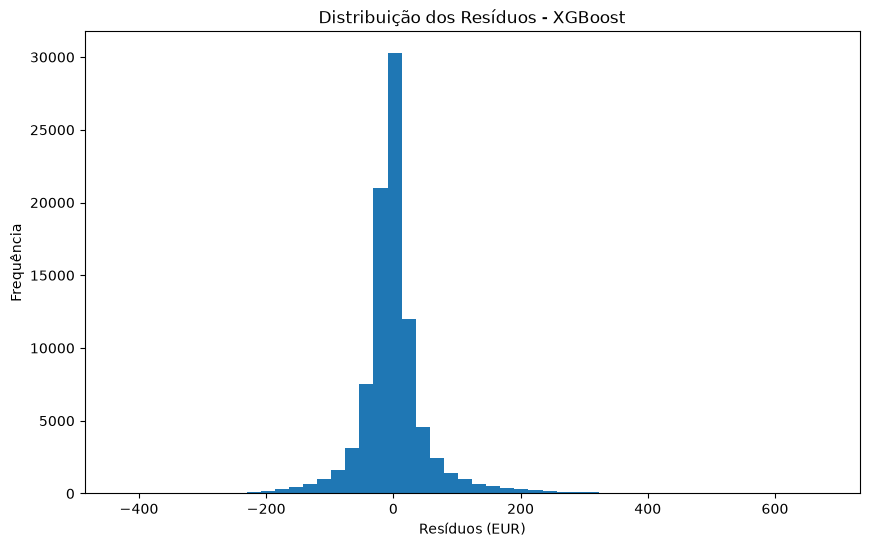

In [6]:
plot_results(y_test, predictions)

## Sem outliers

Os outliers são removidos antes da divisão treino/teste, por isso as métricas deste cenário referem-se apenas a voos
dentro do intervalo IQR de duração, antecedência e preço.

In [7]:
data_iqr = remove_outliers_iqr(data, NUMERIC_FEATURES + [TARGET])
y_test, predictions = run_experiment(data_iqr)

Linear Regression: treinado em 1.05s


Random Forest: treinado em 1074.07s


XGBoost: treinado em 1.88s


In [8]:
metrics_iqr = metrics_table(y_test, predictions, UNIT)
metrics_iqr

,MAE (EUR),RMSE (EUR),R²
Linear Regression,50.081429,72.134866,0.878267
Random Forest,20.223612,39.515050,0.963471
XGBoost,30.272924,48.112289,0.945846


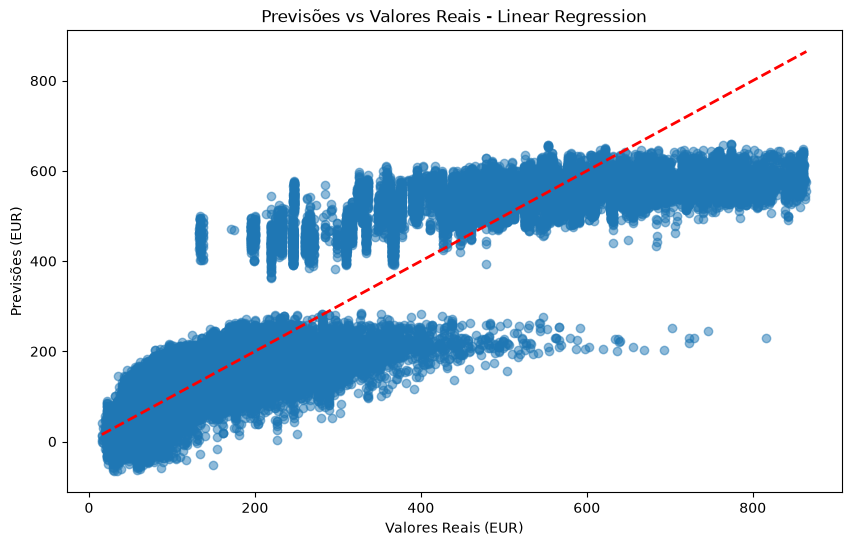

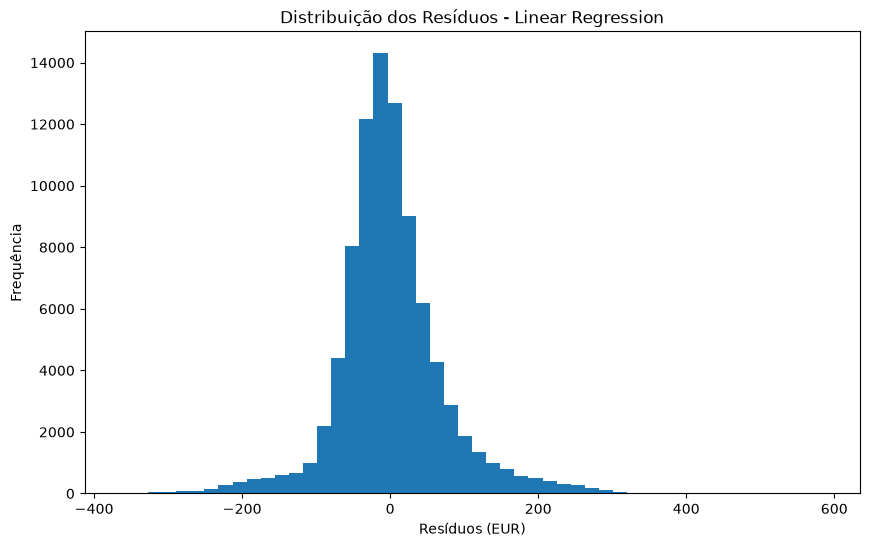

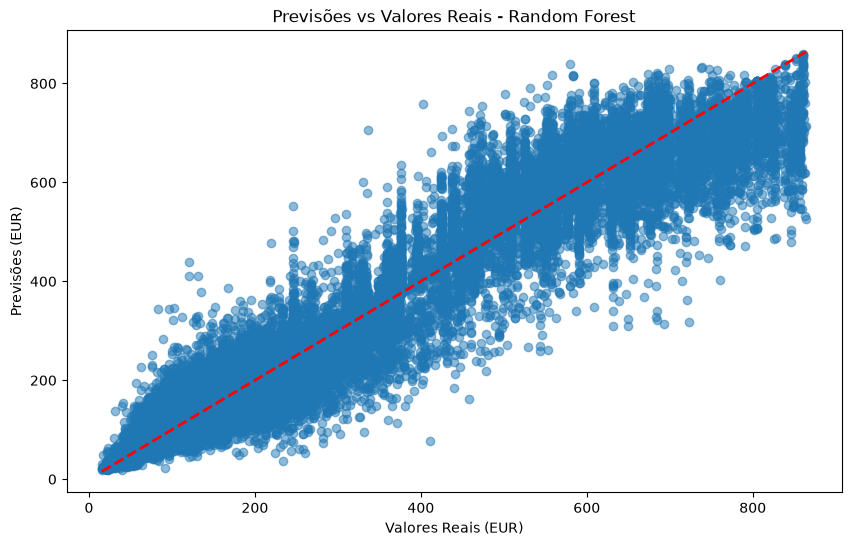

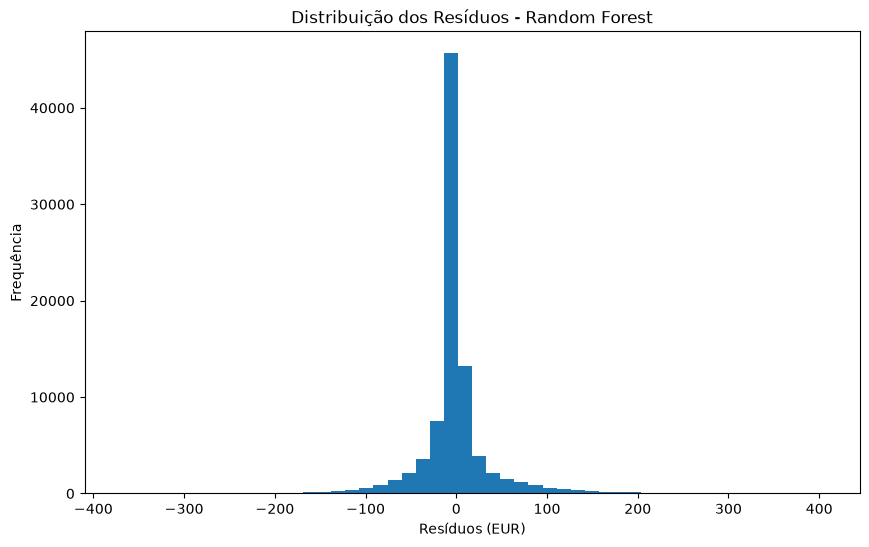

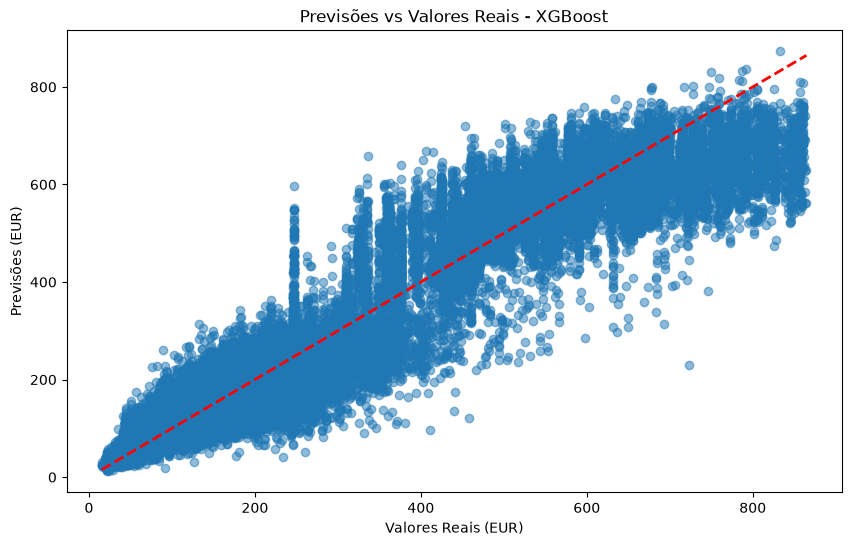

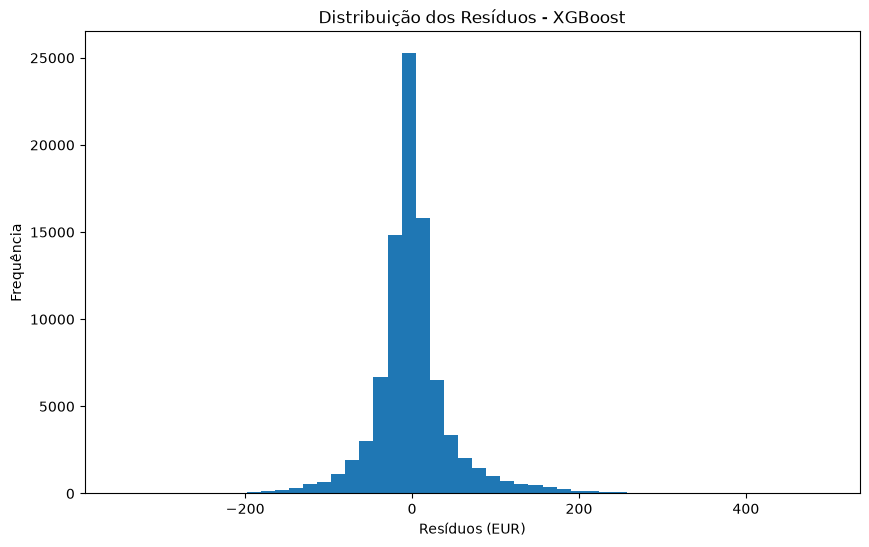

In [9]:
plot_results(y_test, predictions)

## Comparação

In [10]:
pd.concat({"Dados completos": metrics_full, "Sem outliers": metrics_iqr}, names=["Cenário", "Modelo"])

MAE (EUR)  RMSE (EUR)        R²
Cenário         Modelo                                            
Dados completos Linear Regression  56.975761   86.363594  0.853305
                Random Forest      22.881703   47.136021  0.956302
                XGBoost            33.440397   56.591830  0.937011
Sem outliers    Linear Regression  50.081429   72.134866  0.878267
                Random Forest      20.223612   39.515050  0.963471
                XGBoost            30.272924   48.112289  0.945846

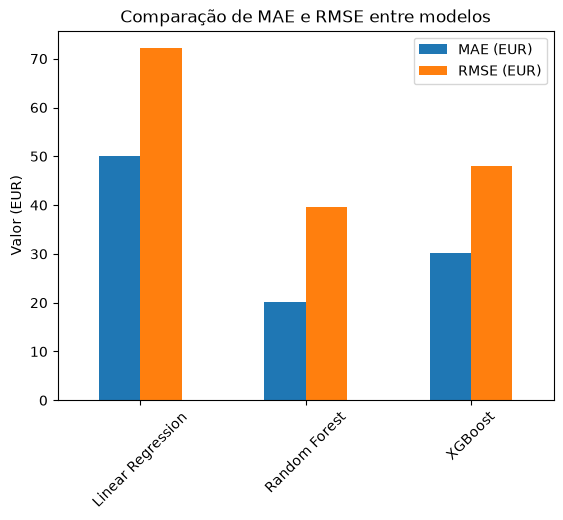

In [11]:
plot_error_comparison(metrics_iqr, UNIT)